# Revenue Growth Drivers & Recorded Inventory Structure in Fashion Retail (2015–2024)

## Project Overview

This project uses validated sales records from 2015–2024, product reference data and a recorded inventory file to investigate how the business changed over time. The sales analysis covers transaction value, unit volume, product prices, discounting, seasonality, markets, product groups and observed customer activity. Inventory is kept separate because its usefulness depends first on whether the recorded stock data is current enough for the question being asked.

The analytical populations are defined according to the metric being calculated. Valid non-cancelled sales can support order, unit and customer activity measures, while net-revenue calculations additionally require a recorded discount. Records containing the unresolved `quantity = 608` value are excluded from headline results because their business meaning has not been confirmed and their scale could materially distort both volume and value measures.


## Business Questions

- What explains the change in nominal net revenue: more orders, more units, higher product prices, a different product mix or discounting?
- Did the growing share of higher nominal price bands reflect different products being purchased, or the same products moving into higher price ranges?
- Was the monthly revenue pattern consistent enough across years to matter for planning?
- Did countries that looked similar in total scale follow similar growth paths?
- Were company-level results also visible within categories and subcategories?
- What does the transaction history show about repeated customer activity, consecutive-year continuity and revenue concentration?
- Is the recorded inventory current enough to support anything beyond a structural comparison?
- Which conclusions remain limited by missing discounts, unresolved source fields, nominal monetary values and inventory freshness?


## Analytical Storyline

To investigate the change in revenue, I begin with data reliability and define which records can support each metric. I then compare revenue with order volume. If transaction count does not account for the change, the analysis moves inside the order and tests unit volume, quantity-weighted gross unit price, product mix and recorded discounting.

Only after the revenue mechanism has been separated into these components do I examine how the observed results are distributed through the calendar, across countries and within product groups. Customer activity is analysed afterwards using measures that do not require assumptions about formal retention. Recorded inventory comes last and is interpreted only within the limits established by its update history.


## Data Sources

The notebook uses three validated outputs produced during the cleaning stage: `sales_orders_core_analysis.csv`, `products_clean.csv` and `inventory_stock_review.csv`.

The loading step checks the standard project locations first. A duplicate-upload suffix is accepted only when it resolves to a single unambiguous file, so the notebook does not silently choose between multiple possible inputs.


## Setup and Input Validation

Before calculating business metrics, the notebook verifies that the required files can be loaded with the expected structure. It checks required columns, identifier quality, product references and the joins needed later in the analysis.

These controls are performed before aggregation so that duplicated keys, unmatched products or invalid fields do not become hidden inside revenue, market or customer summaries.


In [1]:
from pathlib import Path
import calendar

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12



In [2]:
REQUIRED_INPUTS = {
    "sales": "sales_orders_core_analysis.csv",
    "products": "products_clean.csv",
    "inventory": "inventory_stock_review.csv",
}

SEARCH_DIRECTORIES = [
    Path("data/processed"),
    Path("."),
    Path("/content"),
]


def find_input_file(filename: str) -> Path | None:
    exact_matches = [
        directory / filename
        for directory in SEARCH_DIRECTORIES
        if (directory / filename).is_file()
    ]

    if exact_matches:
        return exact_matches[0]

    filename_path = Path(filename)
    duplicate_matches = []

    for directory in SEARCH_DIRECTORIES:
        if directory.exists():
            duplicate_matches.extend(
                directory.glob(
                    f"{filename_path.stem}(*){filename_path.suffix}"
                )
            )

    duplicate_matches = sorted(set(duplicate_matches))

    if len(duplicate_matches) == 1:
        return duplicate_matches[0]

    if len(duplicate_matches) > 1:
        raise FileExistsError(
            f"Multiple versions of {filename} were found: "
            + ", ".join(str(path) for path in duplicate_matches)
            + ". Keep one file or restore the standard filename."
        )

    return None


def resolve_inputs() -> tuple[dict[str, Path], list[str]]:
    resolved = {}
    missing = []

    for key, filename in REQUIRED_INPUTS.items():
        path = find_input_file(filename)

        if path is None:
            missing.append(filename)
        else:
            resolved[key] = path

    return resolved, missing


INPUT_PATHS, missing_files = resolve_inputs()

if missing_files:
    try:
        from google.colab import files as colab_files

        print("Select the missing validated CSV files.")
        colab_files.upload()
        INPUT_PATHS, missing_files = resolve_inputs()

    except ImportError:
        pass

if missing_files:
    raise FileNotFoundError(
        "Missing required files: " + ", ".join(missing_files)
    )

print("Validated inputs:")
for name, path in INPUT_PATHS.items():
    print(f"- {name}: {path}")

Select the missing validated CSV files.


Saving inventory_clean.csv to inventory_clean.csv
Saving inventory_rejected.csv to inventory_rejected.csv
Saving inventory_stock_review.csv to inventory_stock_review.csv
Saving key_findings.csv to key_findings.csv
Saving products_clean.csv to products_clean.csv
Saving products_rejected.csv to products_rejected.csv
Saving quality_issue_summary.csv to quality_issue_summary.csv
Saving sales_orders_clean.csv to sales_orders_clean.csv
Saving sales_orders_core_analysis.csv to sales_orders_core_analysis.csv
Saving sales_orders_rejected.csv to sales_orders_rejected.csv
Validated inputs:
- sales: sales_orders_core_analysis.csv
- products: products_clean.csv
- inventory: inventory_stock_review.csv


In [3]:
sales_core = pd.read_csv(
    INPUT_PATHS["sales"],
    dtype={
        "order_id": "string",
        "customer_id": "string",
        "product_id": "string",
    },
    low_memory=False,
)

products = pd.read_csv(
    INPUT_PATHS["products"],
    dtype={"product_id": "string"},
    low_memory=False,
)

inventory = pd.read_csv(
    INPUT_PATHS["inventory"],
    dtype={"product_id": "string"},
    low_memory=False,
)

sales_core["order_date"] = pd.to_datetime(
    sales_core["order_date"],
    errors="coerce",
)

products["launch_date"] = pd.to_datetime(
    products["launch_date"],
    errors="coerce",
)

inventory["last_stock_update"] = pd.to_datetime(
    inventory["last_stock_update"],
    errors="coerce",
)

for column in [
    "quantity",
    "unit_price",
    "discount_pct",
    "gross_order_value",
    "net_order_value",
]:
    sales_core[column] = pd.to_numeric(
        sales_core[column],
        errors="coerce",
    )

products["base_price"] = pd.to_numeric(
    products["base_price"],
    errors="coerce",
)

for column in ["stock_quantity", "days_since_stock_update"]:
    if column in inventory.columns:
        inventory[column] = pd.to_numeric(
            inventory[column],
            errors="coerce",
        )

print(
    f"Loaded {len(sales_core):,} sales rows, "
    f"{len(products):,} product rows and "
    f"{len(inventory):,} inventory rows."
)


Loaded 254,804 sales rows, 2,500 product rows and 3,715 inventory rows.


In [4]:
EXPECTED_COLUMNS = {
    "sales": {
        "order_id", "order_date", "customer_id", "product_id",
        "quantity", "unit_price", "discount_pct", "country", "status",
        "gross_order_value", "net_order_value",
        "quantity_608_review_flag", "core_analysis_flag",
    },
    "products": {
        "product_id", "category", "sub_category",
        "base_price", "launch_date", "launch_date_status",
    },
    "inventory": {
        "product_id", "warehouse_country", "stock_quantity",
        "last_stock_update", "days_since_stock_update",
        "stale_stock_update_review_flag",
    },
}

frames = {
    "sales": sales_core,
    "products": products,
    "inventory": inventory,
}

for name, required_columns in EXPECTED_COLUMNS.items():
    missing_columns = sorted(required_columns.difference(frames[name].columns))

    if missing_columns:
        raise ValueError(
            f"{name} is missing required columns: {missing_columns}"
        )

if sales_core.empty or products.empty or inventory.empty:
    raise ValueError("At least one required input is empty.")

if sales_core["order_id"].duplicated().any():
    raise ValueError("The sales input contains duplicated order_id values.")

if products["product_id"].duplicated().any():
    raise ValueError("The product reference contains duplicated product_id values.")

if inventory.duplicated(["product_id", "warehouse_country"]).any():
    raise ValueError(
        "The inventory input contains duplicated product-country keys."
    )

product_ids = set(products["product_id"].dropna())

if not sales_core["product_id"].isin(product_ids).all():
    raise ValueError("At least one sales row has no matching product.")

if not inventory["product_id"].isin(product_ids).all():
    raise ValueError("At least one inventory row has no matching product.")

print("Input validation passed.")


Input validation passed.


## Analytical Scope

The same row population is not appropriate for every business question. Sales activity includes valid non-cancelled orders with a recognised product reference and excludes records containing the unresolved `quantity = 608` value. Net-revenue analysis uses this same base but additionally requires a recorded discount, because net revenue cannot be calculated consistently without it.

Revenue, order count, units and weighted unit price are compared on the same assessable population when they are used to explain growth. Customer continuity is defined only as activity in two consecutive calendar years; it is not treated as formal retention. Inventory is compared with 2024 unit sales only at category-share level and is not assumed to represent sufficient or currently available stock.

The recorded `launch_date` is assessed separately before any launch-related interpretation is considered.


In [5]:
def as_boolean(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    normalized = (
        series.astype("string")
        .str.strip()
        .str.casefold()
    )

    mapped = normalized.map({
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    })

    if mapped.isna().any():
        unexpected = sorted(normalized[mapped.isna()].dropna().unique())
        raise ValueError(
            f"Unexpected boolean values: {unexpected}"
        )

    return mapped.astype(bool)


sales_core["quantity_608_review_flag"] = as_boolean(
    sales_core["quantity_608_review_flag"]
)

inventory["stale_stock_update_review_flag"] = as_boolean(
    inventory["stale_stock_update_review_flag"]
)

sales_activity_all_quantities = (
    sales_core.loc[sales_core["status"].ne("CANCELLED")]
    .copy()
)

sales_activity_analysis = (
    sales_activity_all_quantities.loc[
        ~sales_activity_all_quantities["quantity_608_review_flag"]
    ]
    .copy()
)

sales_revenue_all_quantities = (
    sales_activity_all_quantities.loc[
        sales_activity_all_quantities["net_order_value"].notna()
    ]
    .copy()
)

sales_orders_clean = (
    sales_activity_analysis.loc[
        sales_activity_analysis["net_order_value"].notna()
    ]
    .copy()
)

sales_orders_clean["revenue"] = (
    sales_orders_clean["net_order_value"].astype(float)
)

for dataframe in [
    sales_activity_all_quantities,
    sales_activity_analysis,
    sales_revenue_all_quantities,
    sales_orders_clean,
]:
    dataframe["year"] = dataframe["order_date"].dt.year.astype(int)
    dataframe["month"] = dataframe["order_date"].dt.month.astype(int)

sales_activity_products = sales_activity_analysis.merge(
    products[["product_id", "category", "sub_category"]],
    on="product_id",
    how="left",
    validate="many_to_one",
)

sales_revenue_products = sales_orders_clean.merge(
    products[["product_id", "category", "sub_category"]],
    on="product_id",
    how="left",
    validate="many_to_one",
)

inventory_products = inventory.merge(
    products[["product_id", "category", "sub_category"]],
    on="product_id",
    how="left",
    validate="many_to_one",
)

analysis_years = sorted(sales_orders_clean["year"].unique())

if analysis_years != list(range(2015, 2025)):
    raise ValueError(
        "Expected complete analysis years 2015–2024, "
        f"but detected: {analysis_years}"
    )

launch_assessable = sales_core.merge(
    products.loc[
        products["launch_date"].notna(),
        ["product_id", "launch_date"],
    ],
    on="product_id",
    how="inner",
    validate="many_to_one",
)

pre_launch_share_pct = (
    launch_assessable["order_date"]
    .lt(launch_assessable["launch_date"])
    .mean()
    * 100
)

analysis_scope = pd.DataFrame({
    "Analytical Base": [
        "Sales core input",
        "Non-cancelled activity",
        "Activity excluding quantity 608",
        "Net-revenue analysis",
        "Products",
        "Recorded inventory rows",
        "Inventory updates older than 90 days",
    ],
    "Rows": [
        len(sales_core),
        len(sales_activity_all_quantities),
        len(sales_activity_analysis),
        len(sales_orders_clean),
        len(products),
        len(inventory),
        int(inventory["stale_stock_update_review_flag"].sum()),
    ],
})

display(
    analysis_scope.style
    .format({"Rows": lambda value: f"{value:,.0f}".replace(",", " ")})
    .hide(axis="index")
)


Analytical Base,Rows
Sales core input,254 804
Non-cancelled activity,239 389
Activity excluding quantity 608,237 931
Net-revenue analysis,209 315
Products,2 500
Recorded inventory rows,3 715
Inventory updates older than 90 days,3 156


Among sales records matched to a non-missing `launch_date`, 49.3% have an order date earlier than the recorded launch date. This conflict is too large to treat as a small number of exceptions.

I therefore exclude `launch_date` from launch-performance analysis. Until its business definition is clarified at source, using it to compare pre- and post-launch performance would create a timing interpretation that the data cannot support.


## Data-Quality Sensitivity and Revenue Coverage

Two data-quality issues can materially affect later results, so I quantify them before interpreting business performance.

First, I measure how much the unresolved `quantity = 608` records contribute to orders, units and net revenue. Second, I calculate annual net-revenue coverage after excluding orders with missing discounts. The first check tests whether a small number of questionable records can dominate the metrics; the second checks whether missing discounts affect some years much more than others.


In [6]:
def headline_metrics(dataframe: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "Orders": dataframe["order_id"].nunique(),
        "Units": dataframe["quantity"].sum(),
        "Net Revenue": dataframe["net_order_value"].sum(),
    })


including_608 = headline_metrics(sales_revenue_all_quantities)
excluding_608 = headline_metrics(sales_orders_clean)

quantity_sensitivity = pd.DataFrame({
    "Metric": including_608.index,
    "Including quantity 608": including_608.values,
    "Excluding quantity 608": excluding_608.values,
})

quantity_sensitivity["Difference removed"] = (
    quantity_sensitivity["Including quantity 608"]
    - quantity_sensitivity["Excluding quantity 608"]
)

quantity_sensitivity["Removed share (%)"] = (
    quantity_sensitivity["Difference removed"]
    / quantity_sensitivity["Including quantity 608"]
    * 100
)

display(
    quantity_sensitivity.style
    .format({
        "Including quantity 608": lambda value: f"{value:,.0f}".replace(",", " "),
        "Excluding quantity 608": lambda value: f"{value:,.0f}".replace(",", " "),
        "Difference removed": lambda value: f"{value:,.0f}".replace(",", " "),
        "Removed share (%)": "{:.2f}%",
    })
    .hide(axis="index")
)

discount_coverage = (
    sales_activity_analysis
    .groupby("year")
    .agg(
        activity_orders=("order_id", "nunique"),
        revenue_orders=("net_order_value", "count"),
    )
)

discount_coverage["Net-Revenue Coverage (%)"] = (
    discount_coverage["revenue_orders"]
    / discount_coverage["activity_orders"]
    * 100
)

discount_coverage["Missing Discount Share (%)"] = (
    100 - discount_coverage["Net-Revenue Coverage (%)"]
)

discount_coverage = (
    discount_coverage
    .rename(columns={
        "activity_orders": "Activity Orders",
        "revenue_orders": "Orders in Net-Revenue Analysis",
    })
)

discount_coverage.index.name = "Year"

display(
    discount_coverage.style
    .format({
        "Activity Orders": lambda value: f"{value:,.0f}".replace(",", " "),
        "Orders in Net-Revenue Analysis": lambda value: f"{value:,.0f}".replace(",", " "),
        "Net-Revenue Coverage (%)": "{:.1f}%",
        "Missing Discount Share (%)": "{:.1f}%",
    })
    .background_gradient(
        subset=["Missing Discount Share (%)"],
        cmap="Blues",
    )
)

coverage_min = discount_coverage["Net-Revenue Coverage (%)"].min()
coverage_max = discount_coverage["Net-Revenue Coverage (%)"].max()
removed_order_share = quantity_sensitivity.loc[
    quantity_sensitivity["Metric"].eq("Orders"),
    "Removed share (%)",
].iloc[0]

removed_units_share = quantity_sensitivity.loc[
    quantity_sensitivity["Metric"].eq("Units"),
    "Removed share (%)",
].iloc[0]


Metric,Including quantity 608,Excluding quantity 608,Difference removed,Removed share (%)
Orders,210 609,209 315,1 294,0.61%
Units,1 456 975,670 223,786 752,54.00%
Net Revenue,233 473 898,108 077 063,125 396 835,53.71%


,Activity Orders,Orders in Net-Revenue Analysis,Net-Revenue Coverage (%),Missing Discount Share (%)
Year,,,,
2015,23 676,20 840,88.0%,12.0%
2016,23 929,21 092,88.1%,11.9%
2017,23 815,20 977,88.1%,11.9%
2018,23 624,20 682,87.5%,12.5%
2019,23 857,21 084,88.4%,11.6%
2020,23 741,20 880,87.9%,12.1%
2021,23 730,20 852,87.9%,12.1%
2022,23 948,21 022,87.8%,12.2%
2023,23 587,20 810,88.2%,11.8%


The `quantity = 608` value appears in only 0.61% of orders, but those records account for 54.0% of units and 53.7% of assessable net revenue. Their influence is therefore disproportionate to their frequency. Keeping them in the headline population would allow an unresolved value in a very small number of orders to determine more than half of both volume and revenue, so the records remain excluded until the field meaning is confirmed.

Annual net-revenue coverage is much more stable. Between 87.5% and 88.4% of the eligible order population can be assessed in every year after requiring a recorded discount. This consistency reduces the risk that one year is disproportionately affected by missing discounts, although all net-revenue results still describe the assessable population rather than every recorded order.


# Executive Business Overview

## Overall Business Performance

With the analytical population defined, the first business comparison stays at the highest level: annual net revenue, analysed order count and Average Order Value.

These three measures answer a specific first question. Revenue can increase because the business processes more transactions, because the average transaction becomes more valuable, or through a combination of both. This section separates those two components without yet making assumptions about what changed inside the orders. All monetary values are nominal, and Average Order Value describes transaction value rather than margin.


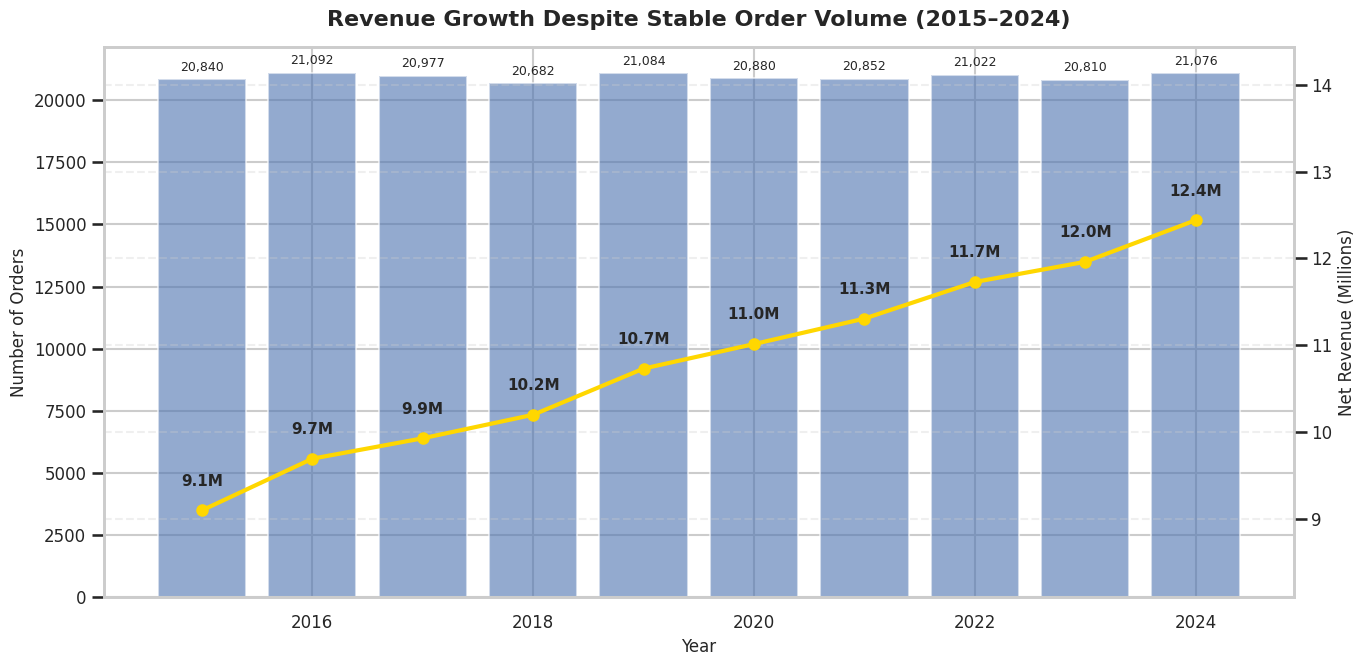

Metric,2015,2024,Change (%)
Average Order Value,436,590,+35.3%


In [7]:
yearly_summary = (
    sales_orders_clean
    .groupby("year", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
    )
)

yearly_summary["Revenue (M)"] = (
    yearly_summary["revenue"] / 1_000_000
)

yearly_summary["Average Order Value"] = (
    yearly_summary["revenue"]
    / yearly_summary["orders"]
)

fig, ax1 = plt.subplots(figsize=(14, 7))

bars = ax1.bar(
    yearly_summary["year"],
    yearly_summary["orders"],
    alpha=0.6,
)

ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Number of Orders", fontsize=12)

for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 350,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=9,
    )

ax2 = ax1.twinx()

ax2.plot(
    yearly_summary["year"],
    yearly_summary["Revenue (M)"],
    color="gold",
    marker="o",
    linewidth=3,
    markersize=8,
)

ax2.set_ylabel("Net Revenue (Millions)", fontsize=12)

for x, y in zip(
    yearly_summary["year"],
    yearly_summary["Revenue (M)"],
):
    ax2.text(
        x,
        y + 0.25,
        f"{y:.1f}M",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax2.set_ylim(
    yearly_summary["Revenue (M)"].min() - 1,
    yearly_summary["Revenue (M)"].max() + 2,
)

plt.title(
    "Revenue Growth Despite Stable Order Volume (2015–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

aov_comparison = yearly_summary.loc[
    yearly_summary["year"].isin([2015, 2024]),
    ["year", "Average Order Value"],
].set_index("year")["Average Order Value"]

aov_change_pct = (
    aov_comparison.loc[2024]
    / aov_comparison.loc[2015]
    - 1
) * 100

display(
    pd.DataFrame({
        "Metric": ["Average Order Value"],
        "2015": [aov_comparison.loc[2015]],
        "2024": [aov_comparison.loc[2024]],
        "Change (%)": [aov_change_pct],
    })
    .style
    .format({
        "2015": "{:,.0f}",
        "2024": "{:,.0f}",
        "Change (%)": "{:+.1f}%",
    })
    .hide(axis="index")
)

# Headline growth metrics used in the interpretation
first_year_summary = yearly_summary.set_index("year").loc[2015]
last_year_summary = yearly_summary.set_index("year").loc[2024]

revenue_growth_pct = (
    last_year_summary["revenue"]
    / first_year_summary["revenue"]
    - 1
) * 100

order_growth_pct = (
    last_year_summary["orders"]
    / first_year_summary["orders"]
    - 1
) * 100

aov_growth_pct = (
    last_year_summary["Average Order Value"]
    / first_year_summary["Average Order Value"]
    - 1
) * 100

order_factor = (
    last_year_summary["orders"]
    / first_year_summary["orders"]
)

aov_factor = (
    last_year_summary["Average Order Value"]
    / first_year_summary["Average Order Value"]
)


Between 2015 and 2024, nominal net revenue increased by 36.8%, while the number of analysed orders increased by only 1.1%. Average Order Value rose from 436 to 590, an increase of 35.3%.

The gap shows that the additional revenue did not come primarily from processing substantially more transactions. It appeared inside the value of the average order.

That still leaves several explanations open. A higher order value could come from more units being purchased, a higher gross price per unit, a different mix of products or a change in discounting. Those possibilities need to be separated before the source of the revenue increase can be identified.


# Understanding Revenue Growth

## Weighted Unit Price and Sales Volume

The order comparison places the unexplained change inside transaction value. I now separate physical sales volume from the gross value of the units being sold.

Annual units sold are compared with a quantity-weighted gross unit price. The weighting matters because products are sold in very different quantities: a product sold thousands of times should influence the measure more than a product sold once. Recorded discounts are kept outside this price measure and checked separately through the effective discount rate.


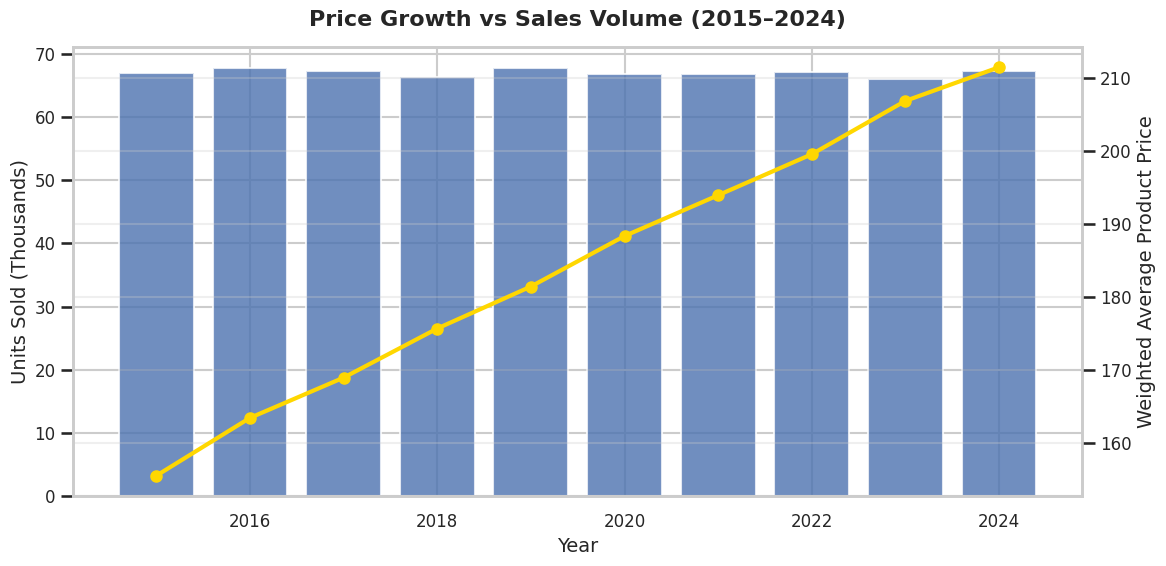

In [8]:
price_volume_summary = (
    sales_orders_clean
    .groupby("year", as_index=False)
    .agg(
        total_quantity=("quantity", "sum"),
        gross_sales_value=("gross_order_value", "sum"),
    )
)

price_volume_summary["weighted_unit_price"] = (
    price_volume_summary["gross_sales_value"]
    / price_volume_summary["total_quantity"]
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    price_volume_summary["year"],
    price_volume_summary["total_quantity"],
    alpha=0.8,
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Units Sold (Thousands)")

ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1000:.0f}")
)

ax2 = ax1.twinx()

ax2.plot(
    price_volume_summary["year"],
    price_volume_summary["weighted_unit_price"],
    color="gold",
    marker="o",
    markersize=8,
    linewidth=3,
)

ax2.set_ylabel("Weighted Average Product Price")

plt.title(
    "Price Growth vs Sales Volume (2015–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

# Price, volume and discount comparison metrics
price_first = price_volume_summary.iloc[0]
price_last = price_volume_summary.iloc[-1]

weighted_price_growth_pct = (
    price_last["weighted_unit_price"]
    / price_first["weighted_unit_price"]
    - 1
) * 100

unit_growth_pct = (
    price_last["total_quantity"]
    / price_first["total_quantity"]
    - 1
) * 100

annual_discount_summary = (
    sales_orders_clean
    .groupby("year")
    .agg(
        net_revenue=("revenue", "sum"),
        gross_value=("gross_order_value", "sum"),
    )
)

annual_discount_summary["effective_discount_pct"] = (
    1
    - annual_discount_summary["net_revenue"]
    / annual_discount_summary["gross_value"]
) * 100

effective_discount_change_pp = (
    annual_discount_summary.loc[2024, "effective_discount_pct"]
    - annual_discount_summary.loc[2015, "effective_discount_pct"]
)


### How Weighted Unit Price Is Calculated

Weighted unit price is calculated as total gross sales value divided by the number of units sold:

\[
\text{Weighted Unit Price}
=
\frac{\sum(\text{Unit Price} \times \text{Quantity})}
{\sum \text{Quantity}}
=
\frac{\text{Gross Sales Value}}
{\text{Units Sold}}
\]

This is different from taking a simple average of product prices. The measure reflects the average gross price of a unit actually sold because each product contributes in proportion to its sold quantity.

Between 2015 and 2024, weighted unit price increased by 36.0%, while analysed units sold changed by only 0.5%. The effective discount rate decreased by just 0.1 percentage points.

**Higher physical sales volume and a material change in discounting do not explain the size of the revenue increase. The main numerical change is the gross value per unit sold.**

Weighted unit price alone cannot show whether customers moved towards different products or whether the same products became more expensive. That distinction is tested next.


## Nominal Price Ranges and Product Mix

To separate price movement from product selection, I use two complementary views.

First, fixed nominal price bands show how the share of sold units moved across Budget, Value, Mid-Range, High-End and Premium ranges. This view is useful visually, but a product can move into a higher band simply because its own price increased.

For that reason, the band comparison is followed by a common-product decomposition using products sold in both 2015 and 2024. Holding product prices and unit shares separately allows the change in weighted price to be split into a product-level price component and a product-share component. The decomposition is descriptive; it does not identify why prices changed.


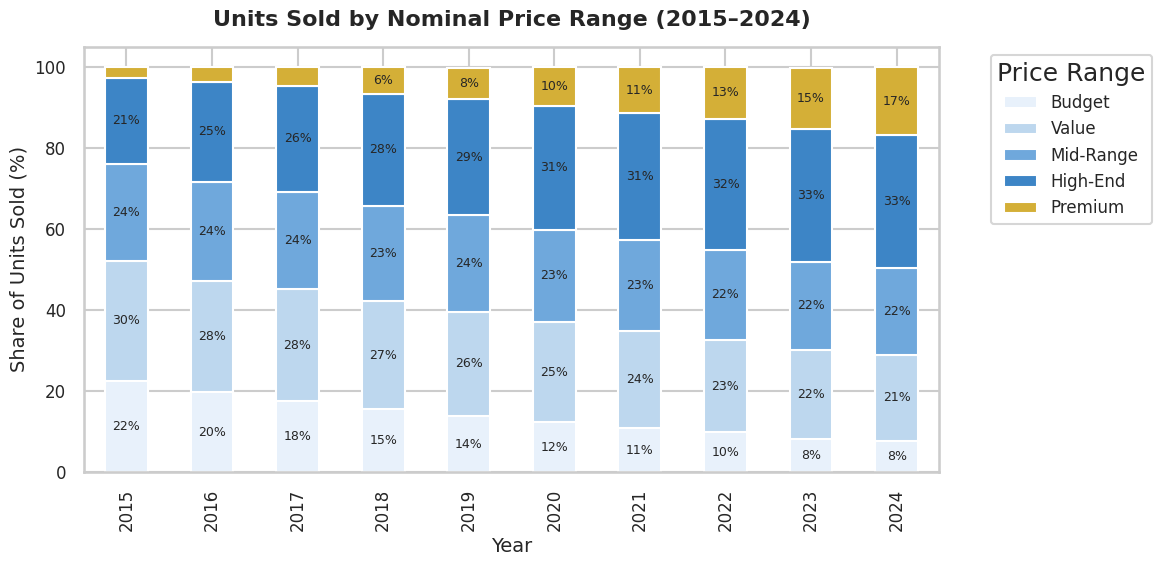

Price Segment,2015 (%),2024 (%),Change (pp)
Budget,22.5%,7.7%,-14.8
Value,29.6%,21.2%,-8.4
Mid-Range,24.0%,21.6%,-2.5
High-End,21.4%,32.7%,+11.3
Premium,2.5%,16.9%,+14.4


In [9]:
price_bins = [0, 100, 150, 200, 300, np.inf]

segment_labels = [
    "Budget",
    "Value",
    "Mid-Range",
    "High-End",
    "Premium",
]

segment_colors = [
    "#E8F1FB",
    "#BDD7EE",
    "#6FA8DC",
    "#3D85C6",
    "#D4AF37",
]

sales_orders_clean["price_segment"] = pd.cut(
    sales_orders_clean["unit_price"],
    bins=price_bins,
    labels=segment_labels,
    include_lowest=True,
)

sales_mix = (
    sales_orders_clean
    .groupby(
        ["year", "price_segment"],
        as_index=False,
        observed=False,
    )
    .agg(
        quantity=("quantity", "sum")
    )
)

sales_mix["share_pct"] = (
    sales_mix["quantity"]
    / sales_mix.groupby("year")["quantity"].transform("sum")
    * 100
)

sales_mix_pivot = (
    sales_mix
    .pivot(
        index="year",
        columns="price_segment",
        values="share_pct"
    )
    .reindex(columns=segment_labels)
    .round(1)
)

ax = sales_mix_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=segment_colors
)

for container in ax.containers:
    bar_labels = [
        f"{bar.get_height():.0f}%"
        if bar.get_height() >= 5
        else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=bar_labels,
        label_type="center",
        fontsize=9
    )

plt.title(
    "Units Sold by Nominal Price Range (2015–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Year")
plt.ylabel("Share of Units Sold (%)")

plt.legend(
    title="Price Range",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

segment_comparison = (
    sales_mix.loc[sales_mix["year"].isin([2015, 2024])]
    .pivot(
        index="price_segment",
        columns="year",
        values="share_pct"
    )
    .reindex(segment_labels)
    .reset_index()
    .rename(columns={
        "price_segment": "Price Segment",
        2015: "2015 (%)",
        2024: "2024 (%)",
    })
)

segment_comparison["Change (pp)"] = (
    segment_comparison["2024 (%)"]
    - segment_comparison["2015 (%)"]
)

display(
    segment_comparison.style
    .format({
        "2015 (%)": "{:.1f}%",
        "2024 (%)": "{:.1f}%",
        "Change (pp)": "{:+.1f}",
    })
    .background_gradient(
        subset=["Change (pp)"],
        cmap="PuBuGn"
    )
    .hide(axis="index")
)


In [10]:
segment_change = (
    segment_comparison
    .sort_values("Change (pp)", ascending=False)
    .reset_index(drop=True)
)

largest_gain = segment_change.iloc[0]
largest_decline = segment_change.iloc[-1]

product_year_price = (
    sales_orders_clean.loc[
        sales_orders_clean["year"].isin([2015, 2024])
    ]
    .groupby(["product_id", "year"])
    .agg(
        units=("quantity", "sum"),
        gross_value=("gross_order_value", "sum"),
    )
)

product_year_price["weighted_unit_price"] = (
    product_year_price["gross_value"]
    / product_year_price["units"]
)

common_products = (
    product_year_price[
        ["units", "weighted_unit_price"]
    ]
    .unstack("year")
    .dropna()
)

units_2015_common = common_products[("units", 2015)]
units_2024_common = common_products[("units", 2024)]
price_2015_common = common_products[("weighted_unit_price", 2015)]
price_2024_common = common_products[("weighted_unit_price", 2024)]

share_2015_common = units_2015_common / units_2015_common.sum()
share_2024_common = units_2024_common / units_2024_common.sum()

common_wup_2015 = (share_2015_common * price_2015_common).sum()
mix_only_wup = (share_2024_common * price_2015_common).sum()
common_wup_2024 = (share_2024_common * price_2024_common).sum()

total_common_price_change_pct = (
    common_wup_2024 / common_wup_2015 - 1
) * 100

mix_effect_pct = (
    mix_only_wup / common_wup_2015 - 1
) * 100

product_price_effect_pct = (
    total_common_price_change_pct - mix_effect_pct
)

mix_effect_share_of_change = (
    mix_effect_pct / total_common_price_change_pct * 100
)

price_effect_share_of_change = (
    product_price_effect_pct / total_common_price_change_pct * 100
)

common_product_coverage_2015 = (
    units_2015_common.sum()
    / product_year_price.xs(2015, level="year")["units"].sum()
    * 100
)

price_mix_decomposition = pd.DataFrame({
    "Component": [
        "Changes in unit shares across products",
        "Changes in product-level prices",
    ],
    "Contribution to Weighted Price Growth (pp)": [
        mix_effect_pct,
        product_price_effect_pct,
    ],
    "Share of Total Increase (%)": [
        mix_effect_share_of_change,
        price_effect_share_of_change,
    ],
})

display(
    price_mix_decomposition.style
    .format({
        "Contribution to Weighted Price Growth (pp)": "{:+.1f}",
        "Share of Total Increase (%)": "{:.1f}%",
    })
    .background_gradient(
        subset=["Share of Total Increase (%)"],
        cmap="Blues",
    )
    .hide(axis="index")
)


Component,Contribution to Weighted Price Growth (pp),Share of Total Increase (%)
Changes in unit shares across products,+0.2,0.5%
Changes in product-level prices,+35.7,99.5%


The nominal price distribution changed substantially. Between 2015 and 2024, the Premium share of sold units increased by 14.4 percentage points and the High-End share by 11.3 points, while the Budget share fell by 14.8 points.

Taken alone, those movements could be read as customers switching towards more expensive products. The common-product comparison changes that interpretation. Within products sold in both years, 99.5% of the increase in weighted unit price is attributed to product-level price changes and only 0.5% to changes in unit shares across products.

**The move towards higher nominal price bands therefore reflects mainly higher recorded prices for individual products, not a major change in the products customers selected.**

This resolves the price-versus-mix question in the available data. It remains a numerical decomposition, not evidence about why prices changed or how profitable those changes were.


# Commercial Performance

## Recurring Monthly Revenue Pattern

The growth-driver analysis explains what changed in transaction value. The calendar view asks a different question: whether revenue is distributed evenly through the year or whether the same high- and low-revenue periods recur.

I aggregate net revenue by calendar month across 2015–2024, then check the strongest and weakest month separately within every year. Average daily revenue is calculated as an additional control so that a month does not appear stronger simply because it contains more days.


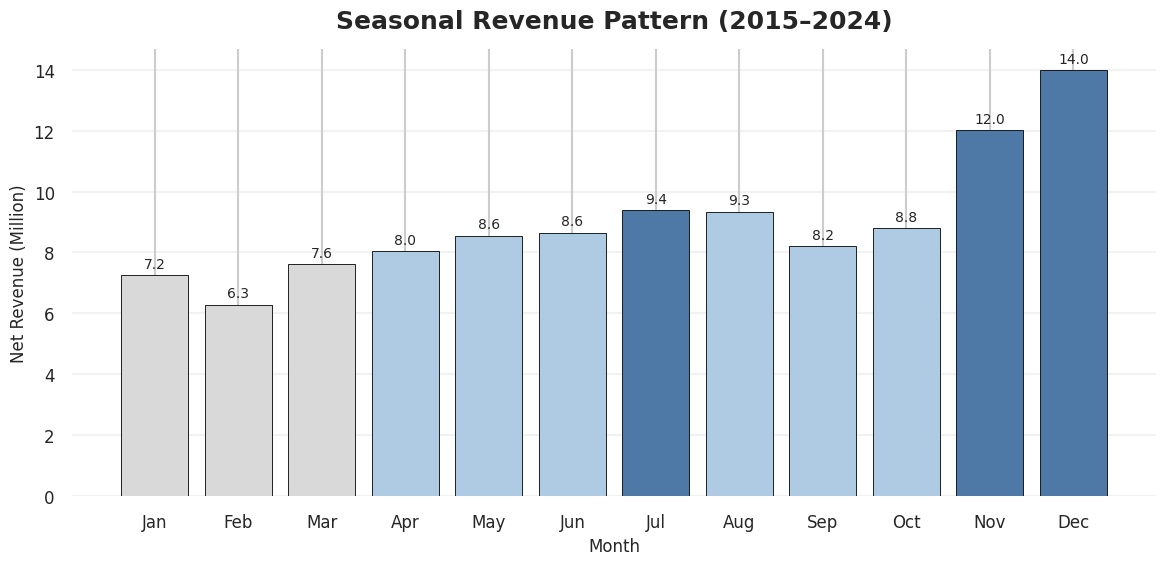

In [11]:
monthly_by_year = (
    sales_orders_clean
    .groupby(["year", "month"], as_index=False)
    .agg(revenue=("revenue", "sum"))
)

monthly_summary = (
    sales_orders_clean
    .groupby("month", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        avg_discount=("discount_pct", "mean"),
    )
)

monthly_summary["Revenue (M)"] = (
    monthly_summary["revenue"] / 1_000_000
)

monthly_summary["Average Discount (%)"] = (
    monthly_summary["avg_discount"]
)

full_date_range = pd.date_range(
    sales_orders_clean["order_date"].min(),
    sales_orders_clean["order_date"].max(),
    freq="D",
)

daily_revenue = (
    sales_orders_clean
    .groupby(sales_orders_clean["order_date"].dt.normalize())["revenue"]
    .sum()
    .reindex(full_date_range, fill_value=0)
)

average_daily_revenue = (
    daily_revenue
    .groupby(daily_revenue.index.month)
    .mean()
)

monthly_summary["Average Daily Revenue"] = (
    monthly_summary["month"].map(average_daily_revenue)
)

top_months = set(
    monthly_summary
    .nlargest(3, "Revenue (M)")["month"]
)

bottom_months = set(
    monthly_summary
    .nsmallest(3, "Revenue (M)")["month"]
)


def get_bar_color(month):
    if month in top_months:
        return "#4E79A7"

    if month in bottom_months:
        return "#D9D9D9"

    return "#AFCBE3"


bar_colors = monthly_summary["month"].map(get_bar_color)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    monthly_summary["month"],
    monthly_summary["Revenue (M)"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6
)

for bar in bars:
    plt.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=bar.get_height() + 0.15,
        s=f"{bar.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "Seasonal Revenue Pattern (2015–2024)",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Month",
    fontsize=12
)

plt.ylabel(
    "Net Revenue (Million)",
    fontsize=12
)

plt.xticks(
    ticks=range(1, 13),
    labels=[
        calendar.month_abbr[m]
        for m in range(1, 13)
    ]
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.box(False)

plt.tight_layout()
plt.show()

# Recurrence and calendar-day checks
strongest_month = monthly_summary.nlargest(
    1, "revenue"
).iloc[0]

weakest_month = monthly_summary.nsmallest(
    1, "revenue"
).iloc[0]

annual_peak_months = monthly_by_year.loc[
    monthly_by_year.groupby("year")["revenue"].idxmax(),
    "month",
]

annual_low_months = monthly_by_year.loc[
    monthly_by_year.groupby("year")["revenue"].idxmin(),
    "month",
]

strongest_month_count = (
    annual_peak_months.eq(int(strongest_month["month"])).sum()
)

weakest_month_count = (
    annual_low_months.eq(int(weakest_month["month"])).sum()
)

daily_ratio = (
    strongest_month["Average Daily Revenue"]
    / weakest_month["Average Daily Revenue"]
)


Across the cumulative monthly totals, February generated 6.3 million in net revenue and December 14.0 million. The annual check confirms that this is not an artefact of combining ten years: December ranked first and February last in every analysed year from 2015 to 2024.

Month length does not explain the gap either. Average daily revenue in December was 2.03 times the February level.

**The year-end increase is therefore a recurring seasonal pattern rather than a result of a few exceptional years or February's shorter calendar.**

This pattern can inform staffing, fulfilment capacity and stock preparation before the strongest months. It does not show whether extra seasonal promotion would increase profit, because campaign cost, margin and incremental sales are not available.


## Distribution by Recorded Discount Range

The next commercial view describes how historical orders and revenue were distributed across recorded discount levels.

Assessable orders are grouped into discount bands, and each band is compared using order share, net-revenue share, Average Order Value and Median Order Value. The purpose is to describe where transactions occurred, not to estimate the causal effect of a discount. Product mix, order quantity, customer profile and campaign context may differ between bands.


In [12]:
discount_bins = [0, 10, 20, 30, 40, 50, np.inf]
discount_labels = [
    "0–10%",
    "10–20%",
    "20–30%",
    "30–40%",
    "40–50%",
    "50%+",
]

sales_orders_clean["discount_range"] = pd.cut(
    sales_orders_clean["discount_pct"],
    bins=discount_bins,
    labels=discount_labels,
    include_lowest=True,
)

discount_summary = (
    sales_orders_clean
    .groupby("discount_range", observed=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        average_order_value=("revenue", "mean"),
        median_order_value=("revenue", "median"),
    )
    .reset_index()
)

discount_summary["Order Share (%)"] = (
    discount_summary["orders"]
    / discount_summary["orders"].sum()
    * 100
)

discount_summary["Revenue Share (%)"] = (
    discount_summary["revenue"]
    / discount_summary["revenue"].sum()
    * 100
)

discount_summary["Revenue (M)"] = (
    discount_summary["revenue"] / 1_000_000
)

discount_summary = (
    discount_summary.rename(columns={
        "discount_range": "Discount Range",
        "orders": "Number of Orders",
        "average_order_value": "Average Order Value",
        "median_order_value": "Median Order Value",
    })
    [
        [
            "Discount Range",
            "Order Share (%)",
            "Revenue Share (%)",
            "Revenue (M)",
            "Number of Orders",
            "Average Order Value",
            "Median Order Value",
        ]
    ]
)

display(
    discount_summary.style
    .format({
        "Order Share (%)": "{:.1f}%",
        "Revenue Share (%)": "{:.1f}%",
        "Revenue (M)": "{:.3f}",
        "Number of Orders": lambda value: f"{value:,.0f}".replace(",", " "),
        "Average Order Value": lambda value: f"{value:,.0f}".replace(",", " "),
        "Median Order Value": lambda value: f"{value:,.0f}".replace(",", " "),
    })
    .background_gradient(
        subset=["Revenue Share (%)", "Revenue (M)"],
        cmap="Greens",
    )
    .background_gradient(
        subset=["Median Order Value"],
        cmap="Blues",
    )
    .hide(axis="index")
)

low_discount = discount_summary.loc[
    discount_summary["Discount Range"].isin(["0–10%", "10–20%"])
]

higher_discount = discount_summary.loc[
    ~discount_summary["Discount Range"].isin(["0–10%", "10–20%"])
]

low_order_share = low_discount["Order Share (%)"].sum()
low_revenue_share = low_discount["Revenue Share (%)"].sum()
higher_order_share = higher_discount["Order Share (%)"].sum()
higher_revenue_share = higher_discount["Revenue Share (%)"].sum()


Discount Range,Order Share (%),Revenue Share (%),Revenue (M),Number of Orders,Average Order Value,Median Order Value
0–10%,42.4%,46.4%,50.160,88 677,566,475
10–20%,36.5%,35.6%,38.444,76 469,503,423
20–30%,17.6%,15.3%,16.572,36 750,451,379
30–40%,3.3%,2.5%,2.714,6 868,395,333
40–50%,0.3%,0.2%,0.180,531,340,286
50%+,0.0%,0.0%,0.006,20,276,222


Orders discounted by no more than 20% represented 78.9% of analysed orders and generated 82.0% of analysed net revenue. The 0–10% band alone accounted for 42.4% of orders and 46.4% of revenue.

Transaction value also declined as recorded discount levels increased. Average Order Value was 566 in the 0–10% band, 503 in the 10–20% band and 451 in the 20–30% band; the median followed the same direction. The 50%+ band contains only 20 orders and is too small to support a stable comparison.

**The highest-value transactions were concentrated in the lower discount ranges, but this does not show that lower discounts caused higher order values.**

Evaluating promotion effectiveness would require product cost, margin, campaign exposure and a valid comparison between otherwise comparable customers or orders.


# Market Performance

## Market Scale and Transaction Value

The company-level results do not show whether the business operated at a similar scale in every country. I therefore begin the market analysis with total net revenue, analysed order count, Average Order Value and average recorded discount over the full period.

This establishes whether market size and transaction value differ materially before any growth ranking is introduced. Profitability and future market potential are outside this comparison because the dataset does not contain market-level cost or margin.


In [13]:
country_summary = (
    sales_orders_clean
    .groupby("country")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        average_discount=("discount_pct", "mean"),
    )
)

country_summary["Average Order Value"] = (
    country_summary["revenue"]
    / country_summary["orders"]
)

country_summary["Revenue (M)"] = (
    country_summary["revenue"] / 1_000_000
)

country_summary = (
    country_summary
    .sort_values("revenue", ascending=False)
    .rename(columns={
        "orders": "Number of Orders",
        "average_discount": "Average Discount (%)",
    })
)

country_summary.index.name = "Country"

display(
    country_summary[
        [
            "Revenue (M)",
            "Number of Orders",
            "Average Order Value",
            "Average Discount (%)",
        ]
    ]
    .style
    .format({
        "Revenue (M)": "{:.2f}",
        "Number of Orders": lambda value: f"{value:,.0f}".replace(",", " "),
        "Average Order Value": lambda value: f"{value:,.0f}".replace(",", " "),
        "Average Discount (%)": "{:.2f}%",
    })
    .background_gradient(
        subset=["Revenue (M)"],
        cmap="Greens",
    )
    .background_gradient(
        subset=["Average Order Value"],
        cmap="Blues",
    )
)

market_spread_pct = (
    (country_summary["revenue"].max() - country_summary["revenue"].min())
    / country_summary["revenue"].mean()
    * 100
)


,Revenue (M),Number of Orders,Average Order Value,Average Discount (%)
Country,,,,
Austria,11.07,21 323,519,12.59%
Slovakia,10.98,21 102,520,12.62%
Poland,10.86,20 982,518,12.52%
Czech Republic,10.81,20 688,522,12.44%
Germany,10.81,20 900,517,12.62%
Spain,10.78,20 917,516,12.52%
Netherlands,10.76,20 993,513,12.50%
Sweden,10.71,20 848,514,12.58%
Italy,10.69,20 812,513,12.56%


The ten-year market totals are tightly grouped. Net revenue ranges from 10.61 million in France to 11.07 million in Austria, a difference equal to only 4.3% of average market revenue. Order counts range from 20,688 to 21,323, Average Order Value from 511 to 522, and average discounts from 12.44% to 12.62%.

At this level, the countries operated at very similar scale and transaction value.

A ten-year total can still hide very different paths to the same destination. The next comparison therefore replaces the cumulative view with endpoint growth and the year-by-year series.


## Market Endpoint Growth

For each country, I compare 2015 net revenue with 2024 and calculate CAGR as an annualised summary of the endpoint change. I also inspect the complete market-year series for year-over-year declines.

The endpoint measure is useful for showing how far each market moved over the period, while the annual check prevents a smooth CAGR from being mistaken for uninterrupted growth.


In [14]:
country_year_revenue = (
    sales_orders_clean
    .groupby(["country", "year"])["revenue"]
    .sum()
    .unstack()
)

country_growth = pd.DataFrame({
    "2015 Revenue (M)": country_year_revenue[2015] / 1_000_000,
    "2024 Revenue (M)": country_year_revenue[2024] / 1_000_000,
})

country_growth["2015–2024 Change (%)"] = (
    country_year_revenue[2024]
    / country_year_revenue[2015]
    - 1
) * 100

country_growth["CAGR (%)"] = (
    (
        country_year_revenue[2024]
        / country_year_revenue[2015]
    ) ** (1 / 9)
    - 1
) * 100

country_growth = country_growth.sort_values(
    "2015–2024 Change (%)",
    ascending=False,
)

country_growth.index.name = "Country"

display(
    country_growth.style
    .format({
        "2015 Revenue (M)": "{:.2f}",
        "2024 Revenue (M)": "{:.2f}",
        "2015–2024 Change (%)": "{:+.1f}%",
        "CAGR (%)": "{:.1f}%",
    })
    .background_gradient(
        subset=["2015–2024 Change (%)"],
        cmap="Greens",
    )
)

market_growth_ranking = (
    country_growth["2015–2024 Change (%)"]
    .sort_values(ascending=False)
)

growth_range_pp = (
    market_growth_ranking.max()
    - market_growth_ranking.min()
)

negative_market_yoy_count = int(
    country_year_revenue
    .pct_change(axis=1)
    .lt(0)
    .sum()
    .sum()
)


,2015 Revenue (M),2024 Revenue (M),2015–2024 Change (%),CAGR (%)
Country,,,,
France,0.87,1.22,+40.4%,3.8%
Slovakia,0.92,1.27,+39.3%,3.7%
Spain,0.90,1.25,+38.3%,3.7%
Germany,0.92,1.27,+38.1%,3.7%
Austria,0.95,1.31,+37.4%,3.6%
Italy,0.90,1.22,+36.5%,3.5%
Netherlands,0.89,1.22,+36.2%,3.5%
Poland,0.93,1.25,+35.2%,3.4%
Sweden,0.93,1.24,+33.9%,3.3%


Every market ended 2024 above its 2015 net-revenue level. France recorded the largest endpoint increase at 40.4% with a CAGR of 3.8%, while the Czech Republic recorded the smallest increase at 32.8% with a CAGR of 3.2%. The spread between the highest and lowest endpoint growth rates was 7.6 percentage points.

The annual paths were not uniformly positive. Across all market-year comparisons, there were 13 year-over-year revenue declines.

**The countries looked similar in total scale, but they did not reach that scale through identical or uninterrupted growth paths.**

This is a revenue comparison rather than a profitability ranking. Margin, market conditions and cost-to-serve would be needed before one country could be labelled the strongest commercial market.


### Category Mix within Markets

One possible explanation for different country growth paths is that markets sell different product structures. To check this, I calculate the share of each country's revenue generated by the main product categories.

Using shares rather than absolute revenue keeps the comparison focused on portfolio composition. If category mixes differ strongly, assortment could be one area to investigate; if they are similar, the growth differences must be sought elsewhere.


In [15]:
country_category = (
    sales_revenue_products
    .groupby(["country", "category"], as_index=False)
    .agg(revenue=("revenue", "sum"))
)

country_category["share_pct"] = (
    country_category["revenue"]
    / country_category.groupby("country")["revenue"].transform("sum")
    * 100
)

ranked_categories = (
    country_category
    .sort_values(
        ["country", "share_pct"],
        ascending=[True, False],
    )
    .assign(
        rank=lambda dataframe:
            dataframe.groupby("country").cumcount() + 1
    )
)

top_category = (
    ranked_categories.loc[
        ranked_categories["rank"].eq(1),
        ["country", "category", "share_pct"],
    ]
    .rename(columns={
        "category": "Top Category",
        "share_pct": "Top Share (%)",
    })
)

second_category = (
    ranked_categories.loc[
        ranked_categories["rank"].eq(2),
        ["country", "category", "share_pct"],
    ]
    .rename(columns={
        "category": "Second Category",
        "share_pct": "Second Share (%)",
    })
)

top2_summary = top_category.merge(
    second_category,
    on="country",
    how="inner",
    validate="one_to_one",
)

top2_summary["Top 2 Share (%)"] = (
    top2_summary["Top Share (%)"]
    + top2_summary["Second Share (%)"]
)

top2_summary = top2_summary.rename(
    columns={"country": "Country"}
)

display(
    top2_summary.style
    .format({
        "Top Share (%)": "{:.1f}%",
        "Second Share (%)": "{:.1f}%",
        "Top 2 Share (%)": "{:.1f}%",
    })
    .background_gradient(
        subset=["Top 2 Share (%)"],
        cmap="Blues",
    )
    .hide(axis="index")
)


Country,Top Category,Top Share (%),Second Category,Second Share (%),Top 2 Share (%)
Austria,Shoes,29.0%,Women,24.2%,53.2%
Czech Republic,Shoes,28.6%,Women,24.7%,53.3%
France,Shoes,28.6%,Women,24.0%,52.6%
Germany,Shoes,29.2%,Women,24.4%,53.6%
Italy,Shoes,28.7%,Women,24.6%,53.2%
Netherlands,Shoes,28.3%,Women,24.6%,52.9%
Poland,Shoes,28.2%,Women,24.7%,52.9%
Slovakia,Shoes,29.1%,Women,24.1%,53.2%
Spain,Shoes,27.8%,Women,24.7%,52.5%
Sweden,Shoes,28.4%,Women,24.2%,52.6%


Shoes ranked first in every market, accounting for 27.8% to 29.2% of country revenue. Women ranked second everywhere, with shares between 24.0% and 24.7%. Together, the two categories generated 52.5% to 53.6% of revenue in each country.

The leading category structure was therefore remarkably consistent across markets.

**Differences in country growth cannot be explained simply by one market relying on a radically different leading product mix.**

The table does not identify the remaining causes. Prices, customer behaviour, availability, local competition and margin would need to be examined before drawing a market-specific commercial conclusion.


# Product Portfolio Performance

## Category Growth Drivers

The market analysis shows that the leading portfolio structure is broadly shared across countries. I now move to the company-level product portfolio and compare how each major category changed between 2015 and 2024.

For every category, net-revenue growth is read together with changes in analysed orders, units, quantity-weighted gross unit price and effective discount rate. This prevents a category from being judged on revenue alone when the same revenue increase can come from very different combinations of volume and price.


In [16]:
category_metrics = (
    sales_revenue_products
    .groupby(["year", "category"])
    .agg(
        revenue=("revenue", "sum"),
        gross_value=("gross_order_value", "sum"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum"),
    )
)

category_metrics["weighted_unit_price"] = (
    category_metrics["gross_value"]
    / category_metrics["units"]
)

category_metrics["effective_discount_pct"] = (
    1
    - category_metrics["revenue"]
    / category_metrics["gross_value"]
) * 100

metrics_2015 = category_metrics.loc[2015]
metrics_2024 = category_metrics.loc[2024]

category_driver_summary = pd.DataFrame(
    index=metrics_2015.index
)

category_driver_summary["2015 Revenue (M)"] = (
    metrics_2015["revenue"] / 1_000_000
)

category_driver_summary["2024 Revenue (M)"] = (
    metrics_2024["revenue"] / 1_000_000
)

for output_column, source_column in {
    "Revenue Growth (%)": "revenue",
    "Orders Growth (%)": "orders",
    "Units Growth (%)": "units",
    "Weighted Unit Price Growth (%)": "weighted_unit_price",
}.items():
    category_driver_summary[output_column] = (
        metrics_2024[source_column]
        / metrics_2015[source_column]
        - 1
    ) * 100

category_driver_summary["Effective Discount Change (pp)"] = (
    metrics_2024["effective_discount_pct"]
    - metrics_2015["effective_discount_pct"]
)

category_driver_summary = (
    category_driver_summary
    .sort_values("Revenue Growth (%)", ascending=False)
)

category_driver_summary.index.name = "Category"

display(
    category_driver_summary.style
    .format({
        "2015 Revenue (M)": "{:.2f}",
        "2024 Revenue (M)": "{:.2f}",
        "Revenue Growth (%)": "{:+.1f}%",
        "Orders Growth (%)": "{:+.1f}%",
        "Units Growth (%)": "{:+.1f}%",
        "Weighted Unit Price Growth (%)": "{:+.1f}%",
        "Effective Discount Change (pp)": "{:+.1f}",
    })
    .background_gradient(
        subset=["Revenue Growth (%)"],
        cmap="Greens",
    )
    .background_gradient(
        subset=["Weighted Unit Price Growth (%)"],
        cmap="Blues",
    )
)

category_growth_ranking = (
    category_driver_summary["Revenue Growth (%)"]
    .sort_values(ascending=False)
)

category_year_revenue = (
    category_metrics["revenue"]
    .unstack("year")
)

negative_category_yoy_count = int(
    category_year_revenue
    .pct_change(axis=1)
    .lt(0)
    .sum()
    .sum()
)


,2015 Revenue (M),2024 Revenue (M),Revenue Growth (%),Orders Growth (%),Units Growth (%),Weighted Unit Price Growth (%),Effective Discount Change (pp)
Category,,,,,,,
Accessories,1.36,1.94,+42.5%,+4.0%,+4.3%,+37.0%,+0.2
Women,2.21,3.07,+38.9%,+1.2%,+1.5%,+36.4%,-0.3
Shoes,2.55,3.52,+37.8%,+1.5%,+1.1%,+35.8%,-0.3
Kids,1.10,1.48,+34.4%,-0.1%,-0.9%,+35.6%,-0.0
Men,1.87,2.43,+30.3%,-0.9%,-3.4%,+35.0%,+0.1


For each category-year, weighted unit price is calculated using the same definition as in the overall analysis:

\[
\text{Category Weighted Unit Price}
=
\frac{\text{Category Gross Sales Value}}
{\text{Category Units Sold}}
\]

Accessories recorded the largest nominal revenue increase at 42.5%. Orders increased by 4.0%, units by 4.3% and weighted unit price by 37.0%. Men recorded the smallest revenue increase at 30.3%; its orders fell by 0.9% and units by 3.4%, while weighted unit price still increased by 35.0%. Shoes remained the largest category by 2024 net revenue at 3.52 million.

Across all major categories, weighted unit prices increased by roughly 35–37%, while order and unit changes were much smaller. Effective discount rates moved by less than one percentage point in every category.

**The company-level price-led pattern is visible within the major categories as well, although the size of revenue and volume changes differs by category.**

The category totals establish the long-term growth picture. Separate views are still needed to see whether the seasonal pattern is broad across categories and whether endpoint growth differs more sharply at subcategory level.


## Monthly Revenue by Product Category

The company-level calendar analysis established a recurring year-end peak. This section checks whether that timing is shared across the product portfolio or mainly reflects the largest category.

The heatmap shows absolute monthly net revenue for each category. Because categories differ in size, I read the pattern horizontally within each row and calculate each category's monthly revenue share to identify its own strongest month. Darker cells should not be compared between rows as if they represented equal category scale.


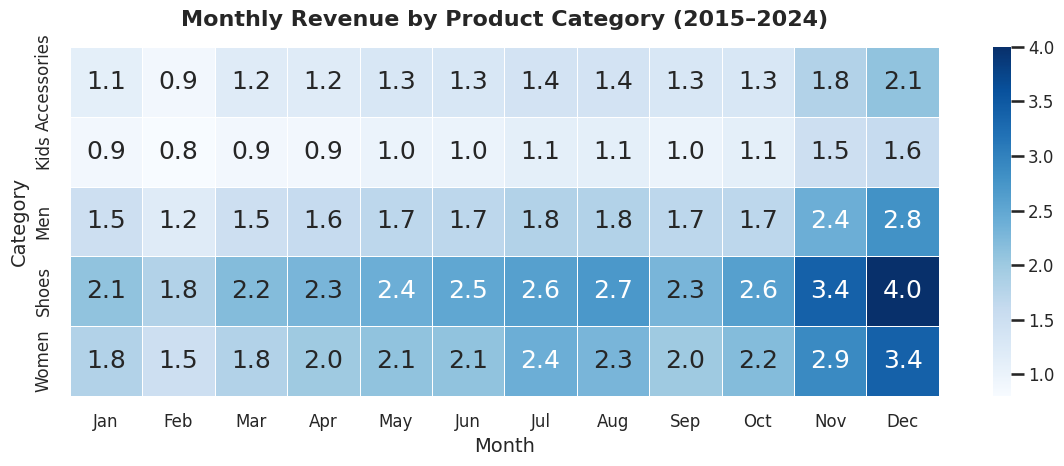

Category,Peak Month,Revenue Share (%)
Men,Dec,13.2%
Shoes,Dec,13.0%
Accessories,Dec,12.9%
Women,Dec,12.8%
Kids,Dec,12.7%


In [17]:
category_month = (
    sales_revenue_products
    .groupby(["month", "category"], as_index=False)
    .agg(revenue=("revenue", "sum"))
)

category_month["Revenue (M)"] = (
    category_month["revenue"] / 1_000_000
)

category_month["Revenue Share (%)"] = (
    category_month["revenue"]
    / category_month.groupby("category")["revenue"].transform("sum")
    * 100
)

category_month_pivot = (
    category_month
    .pivot(
        index="category",
        columns="month",
        values="Revenue (M)"
    )
    .round(1)
)

category_month_pivot.columns = [
    calendar.month_abbr[m]
    for m in category_month_pivot.columns
]

plt.figure(figsize=(12, 5))

sns.heatmap(
    category_month_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

plt.title(
    "Monthly Revenue by Product Category (2015–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

category_peak_months = (
    category_month.loc[
        category_month.groupby("category")["Revenue Share (%)"].idxmax(),
        ["category", "month", "Revenue Share (%)"],
    ]
    .sort_values("Revenue Share (%)", ascending=False)
)

category_peak_months["Peak Month"] = (
    category_peak_months["month"]
    .map(calendar.month_abbr.__getitem__)
)

display(
    category_peak_months[
        ["category", "Peak Month", "Revenue Share (%)"]
    ]
    .rename(columns={"category": "Category"})
    .style
    .format({"Revenue Share (%)": "{:.1f}%"})
    .hide(axis="index")
)


Every major category generated its highest monthly share of ten-year revenue in December. The peak share ranged from 12.7% for Kids to 13.2% for Men. In absolute terms, December revenue ranged from 1.6 million for Kids to 4.0 million for Shoes.

The repeated timing shows that the year-end peak is not created by one category. Shoes and Women contribute more revenue because they are larger categories, but the seasonal direction appears across the full portfolio.

**Year-end capacity planning should therefore be treated as a portfolio-wide issue rather than a response to one unusually seasonal category.**

The heatmap describes timing and scale, not the underlying cause. It cannot separate demand, pricing, promotion or product availability.


## Subcategory Endpoint Growth

Major categories can hide much larger differences between individual product lines. I therefore repeat the 2015-to-2024 endpoint comparison at subcategory level.

Before ranking the strongest and weakest changes, I check the number of analysed orders in both endpoint years. This reduces the risk that a very small subcategory appears extreme only because it is based on a handful of transactions. The ranking still describes endpoints rather than the full annual path.


In [18]:
subcategory_year = (
    sales_revenue_products
    .groupby(["category", "sub_category", "year"])
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
    )
)

subcategory_revenue = subcategory_year["revenue"].unstack()
subcategory_orders = subcategory_year["orders"].unstack()

subcategory_summary = pd.DataFrame({
    "2015 Revenue (M)": subcategory_revenue[2015] / 1_000_000,
    "2024 Revenue (M)": subcategory_revenue[2024] / 1_000_000,
    "2015 Orders": subcategory_orders[2015],
    "2024 Orders": subcategory_orders[2024],
})

subcategory_summary["2015–2024 Change (%)"] = (
    subcategory_revenue[2024]
    / subcategory_revenue[2015]
    - 1
) * 100

minimum_orders = int(
    subcategory_summary[["2015 Orders", "2024 Orders"]]
    .min()
    .min()
)

subcategory_sorted = subcategory_summary.sort_values(
    "2015–2024 Change (%)"
)

lowest_growth = (
    subcategory_sorted
    .head(3)
    .assign(Result="Lowest 3")
)

highest_growth = (
    subcategory_sorted
    .tail(3)
    .iloc[::-1]
    .assign(Result="Highest 3")
)

subcategory_highlights = (
    pd.concat([highest_growth, lowest_growth])
    .reset_index()
    .rename(columns={
        "category": "Category",
        "sub_category": "Subcategory",
    })
)

display(
    subcategory_highlights[
        [
            "Result",
            "Category",
            "Subcategory",
            "2015 Revenue (M)",
            "2024 Revenue (M)",
            "2015 Orders",
            "2024 Orders",
            "2015–2024 Change (%)",
        ]
    ]
    .style
    .format({
        "2015 Revenue (M)": "{:.3f}",
        "2024 Revenue (M)": "{:.3f}",
        "2015 Orders": lambda value: f"{value:,.0f}".replace(",", " "),
        "2024 Orders": lambda value: f"{value:,.0f}".replace(",", " "),
        "2015–2024 Change (%)": "{:+.1f}%",
    })
    .background_gradient(
        subset=["2015–2024 Change (%)"],
        cmap="Greens",
    )
    .hide(axis="index")
)


Result,Category,Subcategory,2015 Revenue (M),2024 Revenue (M),2015 Orders,2024 Orders,2015–2024 Change (%)
Highest 3,Accessories,Bags,0.244,0.374,705,824,+53.4%
Highest 3,Accessories,Scarves,0.238,0.354,723,735,+49.0%
Highest 3,Accessories,Jewelry,0.278,0.406,854,883,+46.2%
Lowest 3,Men,Outerwear,0.335,0.425,703,676,+27.0%
Lowest 3,Kids,Shoes,0.237,0.303,933,901,+27.9%
Lowest 3,Men,Jeans,0.349,0.449,785,760,+28.8%


Bags recorded the strongest subcategory endpoint increase at 53.4%, followed by Scarves at 49.0% and Jewelry at 46.2%; all three belong to Accessories. The smallest increases were Men's Outerwear at 27.0%, Kids' Shoes at 27.9% and Men's Jeans at 28.8%.

Every highlighted subcategory had at least 614 analysed orders in both 2015 and 2024, so the ranking is not being driven by extremely small groups.

The spread confirms that category totals hide meaningful differences between product lines. It does not show whether those differences were stable through the intervening years or what caused them. Annual price, unit, availability and margin data would be needed before turning the ranking into an assortment decision.


# Customer Insights

## Observed Customer Activity

Annual order totals show how much transaction activity occurred, but they do not reveal how that activity was distributed across individual customers.

I begin with the full 2015–2024 customer history and calculate the number of observed customers, the share who placed more than one order, and the mean and median number of orders per customer. Because a ten-year window gives customers a long time to return, this is a description of repeated observed activity, not an annual retention measure.


In [19]:
customer_orders = (
    sales_activity_analysis
    .groupby("customer_id")
    .agg(orders=("order_id", "nunique"))
)

customer_overview = pd.DataFrame({
    "Metric": [
        "Observed Customers",
        "Customers with More Than One Order (%)",
        "Average Orders per Customer",
        "Median Orders per Customer",
    ],
    "Value": [
        len(customer_orders),
        customer_orders["orders"].gt(1).mean() * 100,
        customer_orders["orders"].mean(),
        customer_orders["orders"].median(),
    ],
})

display(
    customer_overview.style
    .format({
        "Value": lambda value:
            f"{value:,.0f}".replace(",", " ")
            if value >= 100
            else f"{value:.1f}",
    })
    .hide(axis="index")
)

customer_metric_lookup = customer_overview.set_index(
    "Metric"
)["Value"]


Metric,Value
Observed Customers,58 834
Customers with More Than One Order (%),92.3
Average Orders per Customer,4.0
Median Orders per Customer,4.0


The activity base contains 58,834 observed customers. Across the full ten-year history, 92.3% placed more than one order, while both the average and median were 4.0 orders per customer.

The similarity between mean and median suggests that the typical order frequency is not being pulled far away from the centre by a small number of extremely active customers at this summary level.

The 92.3% figure should not be labelled retention. A customer has up to ten years to make another purchase, so the next analysis uses a fixed one-year comparison instead.


## Consecutive-Year Customer Activity

To make customer continuity comparable across time, I calculate the share of active customers in each year from 2016 onward who were also active in the immediately preceding year.

I then compare that customer share with the share of annual net revenue generated by the same group. This shows whether previous-year-active customers contribute revenue roughly in proportion to their presence in the active base. The measure deliberately avoids the term retention because no acquisition cohort, eligibility period or churn rule is defined.


In [20]:
customer_year_activity = (
    sales_activity_analysis[
        ["year", "customer_id"]
    ]
    .drop_duplicates()
    .sort_values(["year", "customer_id"])
)

previous_year_activity = (
    customer_year_activity
    .assign(
        year=lambda dataframe: dataframe["year"] + 1,
        active_in_previous_year=True,
    )
)

customer_year_activity = (
    customer_year_activity
    .merge(
        previous_year_activity,
        on=["year", "customer_id"],
        how="left",
        validate="one_to_one",
    )
)

customer_year_activity["active_in_previous_year"] = (
    customer_year_activity["active_in_previous_year"]
    .eq(True)
)

customer_continuity = (
    customer_year_activity
    .groupby("year")
    .agg(
        active_customers=("customer_id", "nunique"),
        active_in_previous_year=("active_in_previous_year", "sum"),
    )
)

customer_continuity["Previous-Year Active Share (%)"] = (
    customer_continuity["active_in_previous_year"]
    / customer_continuity["active_customers"]
    * 100
)

customer_year_revenue = (
    sales_orders_clean
    .groupby(["year", "customer_id"], as_index=False)
    .agg(revenue=("revenue", "sum"))
    .merge(
        customer_year_activity,
        on=["year", "customer_id"],
        how="left",
        validate="one_to_one",
    )
)

annual_customer_revenue = (
    customer_year_revenue
    .groupby("year")["revenue"]
    .sum()
)

previous_year_customer_revenue = (
    customer_year_revenue.loc[
        customer_year_revenue["active_in_previous_year"]
    ]
    .groupby("year")["revenue"]
    .sum()
)

customer_continuity["Previous-Year Active Revenue Share (%)"] = (
    previous_year_customer_revenue
    / annual_customer_revenue
    * 100
)

customer_continuity = (
    customer_continuity
    .rename(columns={
        "active_customers": "Active Customers",
        "active_in_previous_year": "Active in Previous Year",
    })
)

customer_continuity.loc[
    2015,
    [
        "Previous-Year Active Share (%)",
        "Previous-Year Active Revenue Share (%)",
    ],
] = np.nan

customer_continuity.index.name = "Year"

display(
    customer_continuity.style
    .format({
        "Active Customers": lambda value: f"{value:,.0f}".replace(",", " "),
        "Active in Previous Year": lambda value: f"{value:,.0f}".replace(",", " "),
        "Previous-Year Active Share (%)": "{:.1f}%",
        "Previous-Year Active Revenue Share (%)": "{:.1f}%",
    }, na_rep="Baseline")
    .background_gradient(
        subset=["Previous-Year Active Share (%)"],
        cmap="Blues",
    )
)

latest_consecutive_customer_share = customer_continuity.loc[
    2024,
    "Previous-Year Active Share (%)",
]

latest_consecutive_revenue_share = customer_continuity.loc[
    2024,
    "Previous-Year Active Revenue Share (%)",
]

continuity_min = customer_continuity.loc[
    2016:2024,
    "Previous-Year Active Share (%)",
].min()

continuity_max = customer_continuity.loc[
    2016:2024,
    "Previous-Year Active Share (%)",
].max()


,Active Customers,Active in Previous Year,Previous-Year Active Share (%),Previous-Year Active Revenue Share (%)
Year,,,,
2015,19 588,0,Baseline,Baseline
2016,19 692,6 470,32.9%,32.8%
2017,19 636,6 379,32.5%,32.1%
2018,19 505,6 499,33.3%,33.3%
2019,19 719,6 435,32.6%,32.8%
2020,19 601,6 401,32.7%,32.6%
2021,19 638,6 388,32.5%,32.4%
2022,19 739,6 482,32.8%,32.6%
2023,19 534,6 499,33.3%,33.3%


In 2024, 32.5% of active customers had also purchased in 2023, and those customers generated 33.2% of analysed 2024 net revenue. Across 2016–2024, the previous-year-active customer share stayed within a narrow range of 32.5% to 33.3%.

The revenue contribution of the 2024 previous-year-active group was therefore close to its share of customers rather than disproportionately large.

**Consecutive-year activity was stable across the observed period, but it should be interpreted as continuity of activity rather than formal retention.**

A separate question remains: even if continuity is stable, annual revenue could still depend heavily on a small group of high-spending customers. That is tested with the 2024 concentration curve.


## Customer Revenue Distribution in 2024

Customer continuity and customer concentration answer different questions. The previous measure shows whether customers appear in consecutive years; it does not show how evenly revenue is distributed within one year.

For the concentration analysis, I use 2024 only so every customer is observed over the same complete annual window. Customers are ranked by analysed net revenue, and the cumulative curve measures how much of the active customer base is needed to generate 80% of revenue. I also compare the contribution of the top 10% with the lower 50%.


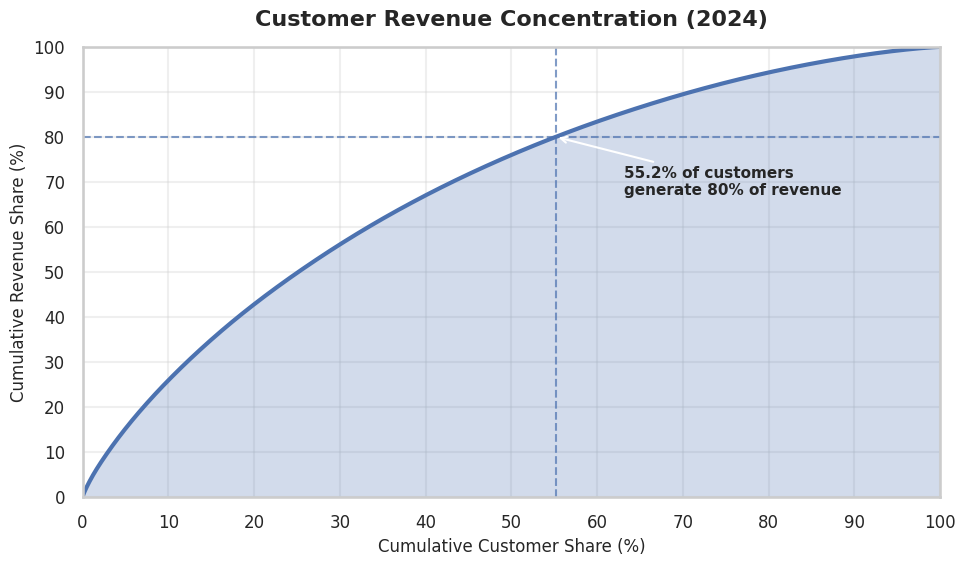

In [21]:
customer_revenue = (
    sales_orders_clean.loc[
        sales_orders_clean["year"].eq(2024)
    ]
    .groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .rename("revenue")
    .reset_index()
)

customer_revenue["Cumulative Revenue Share (%)"] = (
    customer_revenue["revenue"].cumsum()
    / customer_revenue["revenue"].sum()
    * 100
)

customer_revenue["Cumulative Customer Share (%)"] = (
    (customer_revenue.index + 1)
    / len(customer_revenue)
    * 100
)

pareto_80 = (
    customer_revenue.loc[
        customer_revenue["Cumulative Revenue Share (%)"].ge(80),
        "Cumulative Customer Share (%)",
    ]
    .iloc[0]
)

customer_count = len(customer_revenue)
top_10_count = int(np.ceil(customer_count * 0.10))
bottom_50_start = int(np.floor(customer_count * 0.50))

top_10_revenue_share = (
    customer_revenue.iloc[:top_10_count]["revenue"].sum()
    / customer_revenue["revenue"].sum()
    * 100
)

bottom_50_revenue_share = (
    customer_revenue.iloc[bottom_50_start:]["revenue"].sum()
    / customer_revenue["revenue"].sum()
    * 100
)

plt.figure(figsize=(10, 6))

plt.fill_between(
    customer_revenue["Cumulative Customer Share (%)"],
    customer_revenue["Cumulative Revenue Share (%)"],
    alpha=0.25
)

plt.plot(
    customer_revenue["Cumulative Customer Share (%)"],
    customer_revenue["Cumulative Revenue Share (%)"],
    linewidth=3
)

plt.axhline(
    y=80,
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)

plt.axvline(
    x=pareto_80,
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)

plt.annotate(
    f"{pareto_80:.1f}% of customers\ngenerate 80% of revenue",
    xy=(pareto_80, 80),
    xytext=(pareto_80 + 8, 67),
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.5
    )
)

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.xticks(range(0, 101, 10))
plt.yticks(range(0, 101, 10))

plt.xlabel(
    "Cumulative Customer Share (%)",
    fontsize=12
)

plt.ylabel(
    "Cumulative Revenue Share (%)",
    fontsize=12
)

plt.title(
    "Customer Revenue Concentration (2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In 2024, 55.2% of active customers were required to generate 80% of analysed net revenue. The top 10% generated 25.9%, while the lower half generated 24.0%.

This does not resemble a classic 80/20 pattern. Revenue was spread across a relatively broad customer base rather than being dominated by a very small group of high-revenue customers.

**Historical spend alone is therefore not enough to describe customer stability: customer value and continued activity are separate questions.**

The result does not measure profitability or future value. Cost-to-serve, margin, returns and a consistent future observation window would be needed before prioritising customer segments.


# Recorded Inventory Structure Review

## Inventory Coverage and Freshness

The inventory file is not treated as current stock by default. Before comparing it with sales, I first measure how recent its records are.

The file stores recorded product quantities by warehouse country, so I examine the age, median age and date range of the available updates. Only if the snapshot is sufficiently current could it support questions about availability, shortages or replenishment. Otherwise, its use must be limited to a structural comparison.


In [22]:
stale_inventory_share = (
    inventory["stale_stock_update_review_flag"].mean() * 100
)

median_stock_age = inventory["days_since_stock_update"].median()

earliest_stock_update = inventory["last_stock_update"].min()
latest_stock_update = inventory["last_stock_update"].max()

inventory_freshness = pd.DataFrame({
    "Metric": [
        "Recorded Inventory Rows",
        "Products in Inventory File",
        "Rows Older Than 90 Days (%)",
        "Median Age of Recorded Update (Days)",
        "Earliest Recorded Update",
        "Latest Recorded Update",
    ],
    "Value": [
        len(inventory),
        inventory["product_id"].nunique(),
        stale_inventory_share,
        median_stock_age,
        earliest_stock_update.date(),
        latest_stock_update.date(),
    ],
})

display(
    inventory_freshness.style
    .hide(axis="index")
)


Metric,Value
Recorded Inventory Rows,3715
Products in Inventory File,2491
Rows Older Than 90 Days (%),84.952894
Median Age of Recorded Update (Days),303.000000
Earliest Recorded Update,2023-05-12
Latest Recorded Update,2024-12-31


The inventory file contains 3,715 recorded rows covering 2,491 products. Based on the stored freshness fields, 85.0% of rows are older than 90 days and the median recorded age is 303 days. Update dates range from 12 May 2023 to 31 December 2024.

These dates show that the file cannot be interpreted as a current stock snapshot.

**The inventory data is too stale to support conclusions about present shortages, excess stock, warehouse performance or replenishment requirements.**

A limited category-composition comparison is still possible because it does not require the inventory file to equal current available stock.


## Category Composition Compared with 2024 Unit Sales

Given the freshness limitation, I compare structure rather than stock adequacy.

Recorded inventory units and 2024 sold units are converted into category shares. This makes the two datasets comparable at a broad composition level without implying that recorded inventory should equal a full year of sales. Any difference is descriptive only; identifying shortage or excess would require current product-level stock, warehouse mapping, lead times and recent demand.


In [23]:
inventory_by_category = (
    inventory_products
    .groupby("category")["stock_quantity"]
    .sum()
)

units_2024_by_category = (
    sales_activity_products.loc[
        sales_activity_products["year"].eq(2024)
    ]
    .groupby("category")["quantity"]
    .sum()
)

inventory_composition = pd.DataFrame({
    "Recorded Inventory Units": inventory_by_category,
    "2024 Units Sold": units_2024_by_category,
}).fillna(0)

inventory_composition["Recorded Inventory Share (%)"] = (
    inventory_composition["Recorded Inventory Units"]
    / inventory_composition["Recorded Inventory Units"].sum()
    * 100
)

inventory_composition["2024 Units Sold Share (%)"] = (
    inventory_composition["2024 Units Sold"]
    / inventory_composition["2024 Units Sold"].sum()
    * 100
)

inventory_composition["Difference (pp)"] = (
    inventory_composition["Recorded Inventory Share (%)"]
    - inventory_composition["2024 Units Sold Share (%)"]
)

inventory_composition = inventory_composition.sort_values(
    "Difference (pp)",
    ascending=False,
)

inventory_composition.index.name = "Category"

display(
    inventory_composition[
        [
            "Recorded Inventory Share (%)",
            "2024 Units Sold Share (%)",
            "Difference (pp)",
        ]
    ]
    .style
    .format({
        "Recorded Inventory Share (%)": "{:.1f}%",
        "2024 Units Sold Share (%)": "{:.1f}%",
        "Difference (pp)": "{:+.1f}",
    })
    .background_gradient(
        subset=["Difference (pp)"],
        cmap="PuBu",
    )
)

max_unit_gap = (
    inventory_composition["Difference (pp)"]
    .abs()
    .max()
)

largest_positive_unit_gap = (
    inventory_composition["Difference (pp)"]
    .idxmax()
)

largest_negative_unit_gap = (
    inventory_composition["Difference (pp)"]
    .idxmin()
)


,Recorded Inventory Share (%),2024 Units Sold Share (%),Difference (pp)
Category,,,
Women,21.7%,20.8%,+0.9
Shoes,20.4%,19.7%,+0.7
Kids,20.8%,20.6%,+0.2
Men,18.2%,18.8%,-0.5
Accessories,18.9%,20.1%,-1.3


Recorded inventory and 2024 unit sales had a similar category composition. The largest absolute difference was 1.3 percentage points: Accessories represented 18.9% of recorded inventory units and 20.1% of units sold. Women had the largest positive inventory-versus-sales difference at 0.9 percentage points.

The small gaps show structural similarity at category level, but they do not confirm that stock was sufficient or correctly allocated. The inventory records are stale and the two sides of the comparison represent different time bases.

**The inventory file can support a broad composition check, but not an operational stock decision.**


# Executive Conclusions

The conclusions below connect findings only after they have been demonstrated in the notebook. They separate what the data shows directly from questions that would require inflation, margin, campaign or current inventory information.


**Revenue growth came from higher transaction value rather than more transactions.** Between 2015 and 2024, nominal net revenue increased by 36.8%, while analysed order count changed by only 1.1%. Average Order Value increased by 35.3%. Unit volume also remained almost unchanged at +0.5%, so higher physical sales volume cannot explain the size of the revenue increase.

**Higher recorded product prices explain nearly all of the weighted-price increase in the common-product comparison.** Weighted unit price rose by 36.0%. Within products sold in both 2015 and 2024, 99.5% of that increase is attributed to product-level price changes and only 0.5% to changes in product unit shares. The growing Premium and High-End shares should therefore not be read as evidence that customers substantially changed the products they selected.

**The year-end revenue peak was persistent and broad across the portfolio.** December was the strongest month and February the weakest in every analysed year, while average daily revenue in December was 2.03 times the February level. Every major category also reached its highest ten-year monthly revenue share in December, so the pattern is relevant to company-wide capacity planning rather than only one category.

**Recorded sales were concentrated in moderate rather than deep discount ranges, but discount effectiveness cannot be inferred from this distribution.** Orders discounted by no more than 20% represented 78.9% of analysed orders and 82.0% of analysed net revenue. Higher discount bands also had lower observed order values, but campaign exposure, product mix, margin and a valid comparison group are missing, so the analysis does not estimate the incremental effect of discounting.

**Markets looked similar in aggregate scale but followed different growth paths.** Ten-year market revenue differed by only 4.3% of average market revenue, and transaction values were tightly grouped. France nevertheless recorded 40.4% endpoint growth compared with 32.8% in the Czech Republic, and the full market-year series contained 13 year-over-year declines. Similar final scale did not mean identical development over time.

**The price-led pattern was also visible within the product portfolio.** Weighted unit prices increased by roughly 35–37% across every major category while changes in orders and units were much smaller. Accessories recorded the strongest category endpoint growth at 42.5%, while Men recorded 30.3% despite a 3.4% decline in units. Subcategory results widened the range further, from 53.4% growth for Bags to 27.0% for Men's Outerwear.

**Customer activity was recurring, but annual revenue was not concentrated in a narrow group of customers.** In 2024, 32.5% of active customers had also purchased in 2023 and generated 33.2% of analysed revenue. At the same time, 55.2% of active customers were required to generate 80% of 2024 revenue, so the customer base did not follow a classic 80/20 pattern. Consecutive-year activity remains a continuity measure rather than formal retention.

**Recorded inventory was structurally similar to 2024 unit sales, but it was not current enough for optimisation.** The largest category-share difference was 1.3 percentage points, yet 85.0% of inventory rows were older than 90 days and the median recorded age was 303 days. The file can support a broad composition review, not conclusions about present shortages, excess stock or replenishment.


# Business Recommendations

**Monitor value and volume separately.** Revenue, analysed orders, units, Average Order Value and weighted unit price should be reviewed together. The historical pattern shows why a rise in nominal revenue should not automatically be interpreted as stronger demand. Inflation-adjusted revenue and margin would add the missing distinction between nominal growth and stronger commercial performance.

**Evaluate pricing with unit response and profitability, not revenue alone.** Product-level price changes explain most of the observed weighted-price increase, but the dataset cannot show whether those changes improved margin or real performance. Product cost, competitor prices, returns and the unit response after price changes should be added before further pricing decisions are evaluated.

**Prepare operations for the recurring year-end peak.** The December pattern repeats across all analysed years and across every major category, which makes it relevant for staffing, fulfilment capacity and stock preparation. The result supports operational readiness; it does not by itself justify stronger promotional spending.

**Compare markets and product groups through their paths, not only their final revenue.** Similar market totals conceal different annual trajectories, while category and subcategory revenue growth can remain positive even when unit volume is flat or declining. Annual movement, price, units, margin, availability and cost-to-serve should be reviewed before resources are reallocated.

**Track consecutive-year activity as a continuity KPI, not as retention.** The measure is consistent across the observed years and can be broken down further by market or customer segment where sample sizes remain sufficient. A true retention metric requires acquisition cohorts, an eligibility window and a business definition of churn.

**Treat discount analysis as descriptive until campaign and margin data are available.** The current bands show where orders and revenue occurred, but not what would have happened without the discount. Campaign exposure, product margin and a treatment/control or otherwise valid comparison are needed before promotional effectiveness can be assessed.

**Refresh inventory before making stock decisions and resolve source definitions before production reporting.** Current warehouse-level stock, recent product demand, lead times and service levels are required for replenishment or markdown decisions. The business meaning of `quantity = 608`, the definition of `launch_date` and the process creating missing discounts should also be clarified before these fields are used in recurring reporting.


# Limitations and Next Steps

Net-revenue calculations exclude orders with missing discounts, so monetary results describe the assessable population rather than all recorded activity. Annual coverage is stable, but the source of the missing values still needs to be understood. Records containing `quantity = 608` are excluded because their meaning is unresolved and they would dominate both unit and revenue measures. The business definition of `launch_date` also remains unclear.

All monetary comparisons are nominal. Without an inflation index, product cost, contribution margin, returns or fulfilment cost, the notebook cannot determine real revenue growth or profitability by market, category, customer or discount band.

The customer data does not define acquisition dates, eligible cohorts, inactivity rules or churn. Consecutive-year activity is therefore a continuity measure rather than retention, and the available fields do not support a defensible Customer Lifetime Value calculation.

Campaign exposure, acquisition channel and a valid comparison group are unavailable. The notebook can describe associations between observed prices, discounts and revenue, but it cannot determine the causal effect of a promotion, campaign or price change.

Most inventory updates are stale, and the file lacks the current warehouse-level context needed for operational decisions. A future stock analysis would require a confirmed inventory snapshot linked to recent product demand, warehouse mapping, lead times and service-level measures.

The most useful next step is to resolve the source-field definitions first, then add inflation, margin, campaign and current inventory data. Forecasting, causal marketing analysis or prescriptive inventory decisions should be introduced only after those foundations are available.
